In [ ]:
import sys; print(sys.executable)

In [1]:
import os
os.chdir("../")
print(os.getcwd())

d:\git\ServerAnomalyDetection


### 03
- msptのavgとminに相関があるのは理解できるが、逆にそれらとmaxに相関がないのがわからない
- 強い相関のものでも0.95は超えていない
- msptとheapに弱い負の相関が見られる


### 04
- msptのavgとminに0.95+が見られる
- msptとonline_playersに負の相関が見られる

### 03 + 04
- 結合の結果04で見られた特徴はサンプル数による偏りであると考えられる
- `mspt` の `max` は `min` / `avg` とは独立している
    - スパイク型異常の信号は `max` に集約される
- 相関は支配的な程ではない
- 活動期: 高頻度GC、高アロケーション
- アイドル期: 低頻度GC、遅い坂


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from preprocessing.feature_engineer import add_gc_rate

df = pd.read_parquet("data/processed/server_metrics_20260503_20260504.parquet")

df = add_gc_rate(df)    # rate化
df = df.set_index("timestamp")
df = df.iloc[:-1]   # 監視中止の最終行除去
df = df.drop(columns=[
    "gc_count_total", "gc_time_ms_total",   # 累積カラム除去
    "tps", "heap_max_mb"    # 定数カラム除去 ("thread_count")
])
df = df.dropna()

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)
X.describe().round(2)



,mspt_5s_avg,mspt_5s_min,mspt_5s_max,mspt_10s_avg,mspt_10s_min,mspt_10s_max,mspt_1m_avg,mspt_1m_min,mspt_1m_max,heap_used_mb,non_heap_used_mb,cpu_process_pct,thread_count,online_players,gc_count_rate,gc_time_rate_ms
count,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00,2647.00
mean,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.25,-2.53,-0.54,-2.28,-2.57,-0.48,-2.45,-2.55,-0.39,-1.71,-4.68,-0.36,-8.05,-2.55,-0.42,-0.29
25%,-0.79,-0.64,-0.20,-0.75,-0.69,-0.20,-0.81,-0.69,-0.18,-0.77,-0.66,-0.36,0.17,-1.41,-0.42,-0.29
50%,0.15,0.26,-0.07,0.20,0.25,-0.06,0.21,0.34,-0.13,-0.10,0.05,-0.36,0.17,0.87,-0.42,-0.29
75%,0.67,0.62,0.11,0.67,0.63,0.07,0.71,0.65,-0.05,0.58,0.98,-0.36,0.17,0.87,-0.42,-0.29
max,7.44,5.75,41.50,8.03,4.11,29.95,2.55,1.68,12.68,3.27,1.86,25.06,5.11,2.01,5.38,32.23


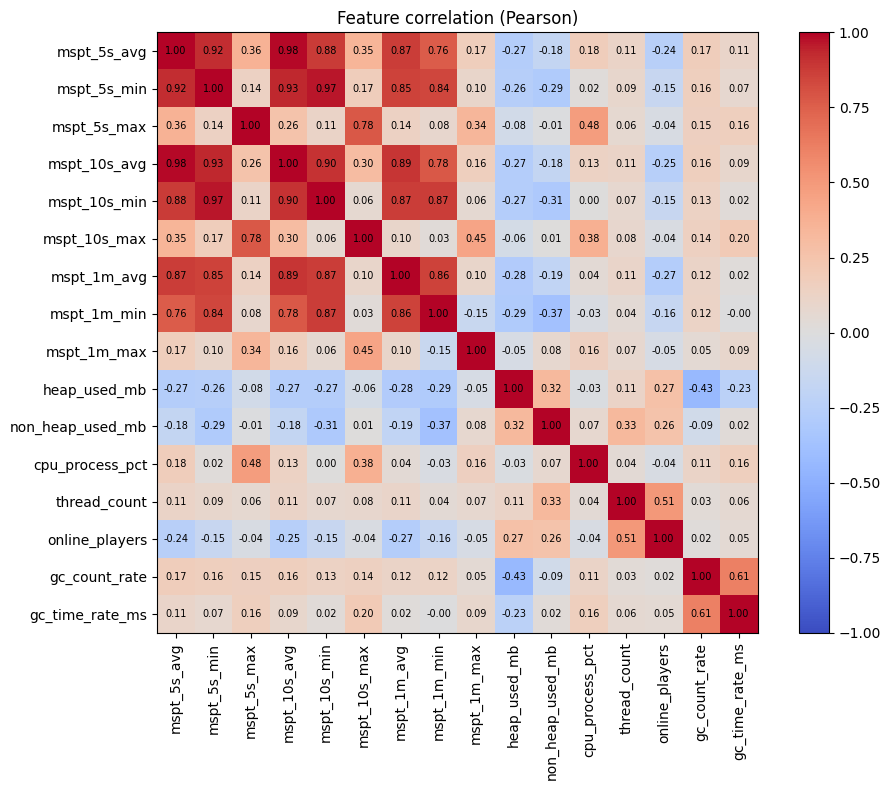

In [7]:
import matplotlib.pyplot as plt

# 相関ヒートマップ
corr = df.corr()    # Pearson

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)  # 0中心の発散カラーマップ

ax.set_xticks(range(len(corr.columns)), labels=corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)), labels=corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax)
ax.set_title("Feature correlation (Pearson)")
plt.tight_layout()
plt.show()


### visualize

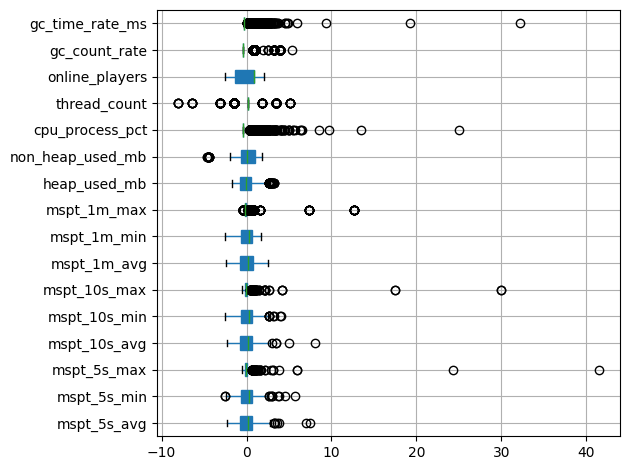

In [8]:
import matplotlib.pyplot as plt

X.boxplot(patch_artist=True, vert=False)
plt.tight_layout()
plt.show()


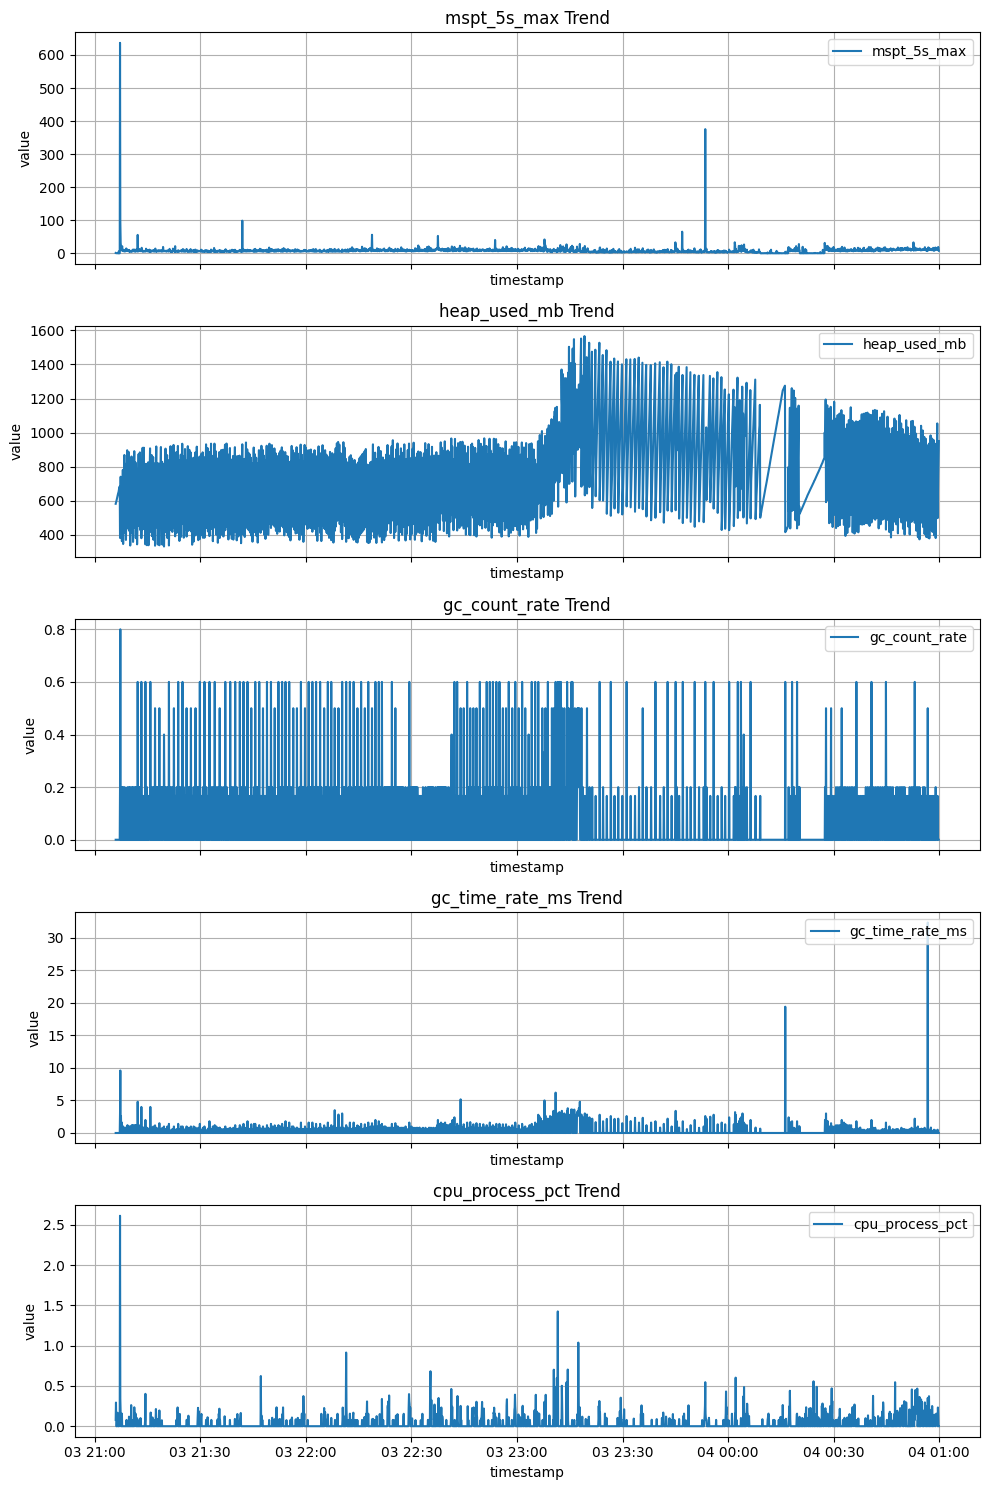

In [ ]:
import matplotlib.pyplot as plt

columns = ["mspt_5s_max", "heap_used_mb", "gc_count_rate", "gc_time_rate_ms", "cpu_process_pct"]
fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(10, 3 * len(columns)), sharex=True)

for ax, column in zip(axes, columns):
    ax.plot(df.index, df[column], label=column)

    ax.set_title(f'{column} Trend')
    ax.set_xlabel('timestamp')
    ax.set_ylabel('value')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.show()
